<a href="https://colab.research.google.com/github/riack16/S100-analitica-datos/blob/main/S100_PS1_Hernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("/content/spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [2]:
# a) Primeras filas
df.head(5)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,3.245900
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2.710000
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2.943600
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2.818217
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,3.150867


In [3]:
# b) Resumen estadístico
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,3.763330
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182,0.997233
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,0.066667
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000,3.130317
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000,3.600000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000,4.226417
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000,8.630167


In [4]:
# c) Canciones por género
df["playlist_genre"].value_counts()


,count
playlist_genre,
edm,6043
rap,5746
pop,5507
r&b,5431
latin,5155
rock,4951


In [5]:
faltan=df.isna().sum()
faltan_2=faltan[faltan>0]
print(faltan_2)

track_name          5
track_artist        5
track_album_name    5
dtype: int64


### 📝 Tu respuesta — Ejercicio 1

**1.** ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno
   muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?

   
>R. Exisitiendo una diferencia de aprox 1000 canciones entre el min y max de generos, considero que se puede trabajar con ellos ya que el total son de 31,733, lo que ese 1000 de diferencia no afectara significativamente en el resultado final.
   Es muy importante que no exista un rango de datos muy amplio porque a la hora de hacer el analisis o graficar, ese sesgo de datos no permitira obtener un resultado preciso.
>
**2.** Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor
   que te haga sospechar de un error de captura? Explica en una frase.

 >R. Revisando el promedio de duracion de las canciones, veo que esta entre los 3.5, por lo que ese valor minimo de 49 segundos se debe revisar ya que puede no considerarse una cancion real, y puede alterar el resultado final, en cambio el valor maximo de 8 minutos, simplemente puede ser una cancion larga, lo cual no es común, se debe revisar pero si considero que se debe mantener en la data final


---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

La media es: 0.70
La mediana es: 0.72
La desviación estándar es: 0.18
El rango es: 1.00




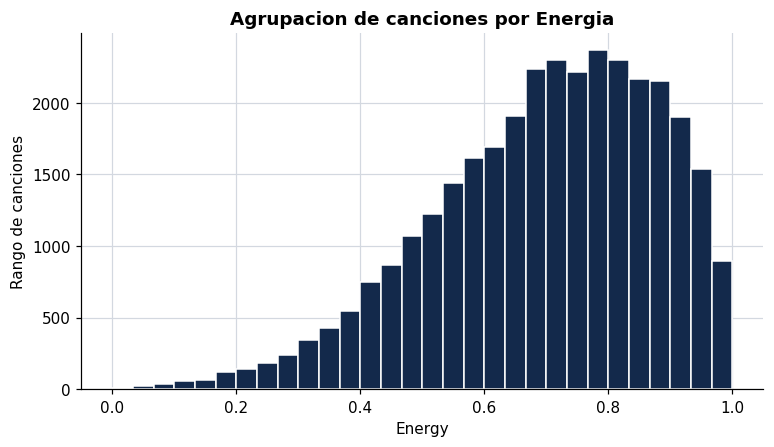



La asimetría es: -0.64


In [6]:
# a) Media, mediana, desviación estándar y rango de energy
print(f"La media es: {df['energy'].mean():.2f}")
print(f"La mediana es: {df['energy'].median():.2f}")
print(f"La desviación estándar es: {df['energy'].std():.2f}")
print(f"El rango es: {(df['energy'].max() - df['energy'].min()):.2f}")

print("\n")
# b) Histograma
plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Energy")
plt.ylabel("Rango de canciones")
plt.title("Agrupacion de canciones por Energia")
plt.show()

print("\n")
# c) Asimetría
print(f"La asimetría es: {df['energy'].skew():.2f}")

### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

> R. Revisando la informacion basica sobre el dataset, sobre la columna energy se obtuvo que la media esta en 0.70; la mediana en 0.72; la desviacion estandar en: 0.18 y el rango en 1.0; lo que indica que existe una diferencia pero descabellada.

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

> R. La media quedó por debajo de la mediana, dando como resultado que la cola jale hacia la izquierda, dando una simetria negativa. por lo que si coincide con lo mostrado en el histograma

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

Media y Desviacion estandar:                 mean   std
playlist_genre            
r&b             0.59  0.18
rap             0.65  0.17
pop             0.70  0.17
latin           0.71  0.15
rock            0.73  0.19
edm             0.80  0.14




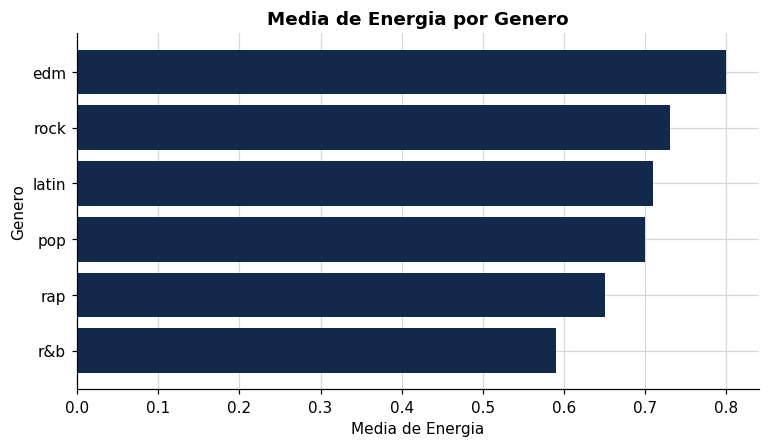

In [7]:
# a) Media y desviación de energy por género

energia_genero = df.groupby("playlist_genre")["energy"].agg(["mean", "std"]).sort_values("mean", ascending=True).round(2)
print(f"Media y Desviacion estandar: {energia_genero}")
print("\n")
# b) Gráfico de barras horizontales

plt.barh(energia_genero.index, energia_genero["mean"], color=AZUL)
plt.xlabel("Media de Energia")
plt.ylabel("Genero")
plt.title("Media de Energia por Genero")
plt.show()
print("\n")



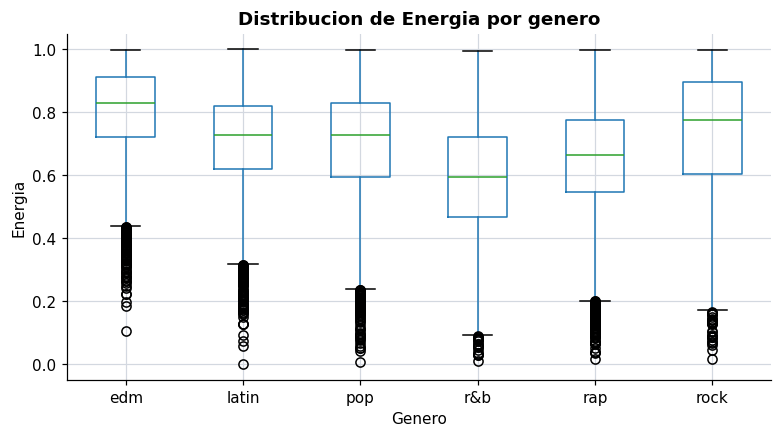

In [8]:
# c) boxplot
ax = df.boxplot(column="energy", by="playlist_genre")
plt.title("Distribucion de Energia por genero")
plt.suptitle("")
plt.xlabel("Genero")
plt.ylabel("Energia")
plt.show()

### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

>R.El genero más enérgico es el EDM (Electronica) con una media de: 0.80 y std de 0.14 y el genero menos enérgico es el r&b con una media de 0.59 y un std de 0.18

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

>R. El genero con mayor dispersion de datos es el rock, por lo que no es el mismo que el mas energico. Que un genero tengas mucha dispersion quiere decir que sus valores no son constantes, es decir que dentro del mismo genero tiene mucha variacion de canciones con diferentes niveles de energy.

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.

>R. Si la coloco en un informe, porque con el titulo y el label en X, se explica bastante lo que quiere decir, "Media de Energia por Genero", solo agregaria un label en Y igual a Genero, pero con el titulo se da a entender

---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

In [9]:
# a) Matriz de correlación
corr =df[audio].corr()
print(f"Matriz de correlacion: \n {corr}")


Matriz de correlacion: 
                   danceability    energy  loudness  speechiness  acousticness  \
danceability          1.000000 -0.086073  0.025335     0.181721     -0.024519   
energy               -0.086073  1.000000  0.676625    -0.032150     -0.539745   
loudness              0.025335  0.676625  1.000000     0.010339     -0.361638   
speechiness           0.181721 -0.032150  0.010339     1.000000      0.026092   
acousticness         -0.024519 -0.539745 -0.361638     0.026092      1.000000   
instrumentalness     -0.008655  0.033247 -0.147824    -0.103424     -0.006850   
liveness             -0.123859  0.161223  0.077613     0.055426     -0.077243   
valence               0.330523  0.151103  0.053384     0.064659     -0.016845   
tempo                -0.184084  0.149951  0.093767     0.044603     -0.112724   
duration_min         -0.096879  0.012611 -0.115058    -0.089431     -0.081581   

                  instrumentalness  liveness   valence     tempo  duration_min  
da

In [10]:
# b) Lista de pares ordenada: el más positivo y el más negativo
pares = corr.unstack()
pares = pares[pares < 0.999] # fuera la diagonal
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
pares = pares.sort_values()
print(f"Lista de pares ordenada: \n {pares}")


Lista de pares ordenada: 
 acousticness      energy             -0.539745
                  loudness           -0.361638
danceability      tempo              -0.184084
instrumentalness  valence            -0.175402
                  loudness           -0.147824
danceability      liveness           -0.123859
duration_min      loudness           -0.115058
acousticness      tempo              -0.112724
instrumentalness  speechiness        -0.103424
danceability      duration_min       -0.096879
duration_min      speechiness        -0.089431
danceability      energy             -0.086073
acousticness      duration_min       -0.081581
                  liveness           -0.077243
duration_min      valence            -0.032225
energy            speechiness        -0.032150
tempo             valence            -0.025732
acousticness      danceability       -0.024519
liveness          valence            -0.020560
acousticness      valence            -0.016845
danceability      instrumentalnes

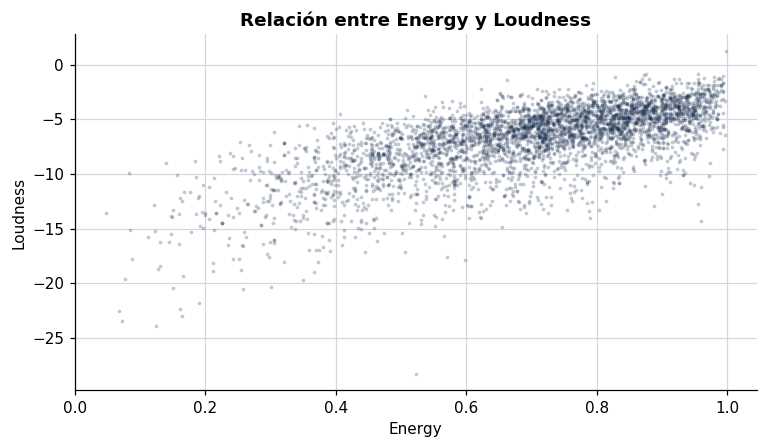

In [11]:
# c) Diagrama de dispersión del par más positivo
m = df.sample(4000, random_state=1)
plt.scatter(m["energy"], m["loudness"], s=6, alpha=0.25, color=AZUL, lw=0)
plt.xlabel("Energy")
plt.ylabel("Loudness")
plt.title("Relación entre Energy y Loudness")
plt.show()

In [12]:
# d) Correlación de cada variable de audio con track_popularity
df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()

,track_popularity
instrumentalness,-0.149872
duration_min,-0.143682
energy,-0.109112
liveness,-0.054584
tempo,-0.005378
speechiness,0.006819
valence,0.033231
loudness,0.057687
danceability,0.064748
acousticness,0.085159


### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

>R. La correlacion positiva mas alta
energy con loudness  r= +0.676625

>La correlacion negativa mas baja
acousticness con energy r= -0.539745

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

> R. La correlacion de +0.676625, es alta pero no lo suficiente para predecir si una cancion con una energia alta tendra un loudness igual de alto, esto quiere decir que pueden existir canciones con la misma energia, pero diferentes loudness, para que esto sea asi, deberia tener una correlacion casi de 1.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

>R. Para esto se debe entender como funciona la creacion de una cancion, pero si utilizamos los datos, ¿se puede afirmar que una variable causa a la otra?
No se puede afirmar directamente, pero si podemos decir que existe una coincidencia ya que tiene una correlacion relativamente alta de un 0.68, pero puede existir un valor oculto que sea realmente la causa de esta relacion.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

> R. La correlacion mas cercana a track_popularity es instrumentalness con un valor de r = -0.15, mantiene una relación débil ya que se aleja bastante de 1. No se puede predecir si una cancion sera popular solo porque l instrumentalness tenga mas popularidad, existen otros factores a tener en cuenta para poder predecir si una canción será popular

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [13]:
# a) Correlación global entre energy y danceability
corr_total = df["energy"].corr(df["danceability"])
print(f"La correlacion entre energy y danceability es: \n {corr_total:.2f}")
print("-----------------------------------------------------------------------------")
print("\n")

# b) La misma correlación dentro de cada género
corr_genero = df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values().round(2)
print(f"Correlacion por Genero: \n {corr_genero}")
print("-----------------------------------------------------------------------------")
print("\n")

# c) Tabla resumen por género

# ---------USO DE IA AQUI HASTA EL FINAL-----------------

# Media de danceability por género
danceability_genero = df.groupby("playlist_genre")["danceability"].mean()

# Media de track_popularity por género
popularity_genero = df.groupby("playlist_genre")["track_popularity"].mean()

# Junta todo en una sola tabla, usando el mismo índice (playlist_genre)
resumen_genero = pd.concat([
    energia_genero["mean"].rename("energy_mean"),
    danceability_genero.rename("danceability_mean"),
    popularity_genero.rename("popularity_mean"),
    corr_genero.rename("corr_energy_dance")
], axis=1)

print(f"Resumen del Genero: \n {resumen_genero}")

print("-----------------------------------------------------------------------------")
print("\n")

# d) Estandarización de energy y canción más extrema
# Estandarización de energy
df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()

# Canción con el z más alto
idx_max = df["energy_z"].idxmax()
print(f"Cancion con Z más Alto:\n {df.loc[idx_max, ["track_name", "track_artist", "playlist_genre", "energy", "energy_z"]]}")
print("-----------------------------------------------------------------------------")
print("\n")

# Comprobaciones
print(f"Media de energy_z: {df['energy_z'].mean():.4f}")
print(f"Desviación de energy_z: {df['energy_z'].std():.4f}")
print(f"Skew de energy: {df['energy'].skew():.4f}")
print(f"Skew de energy_z: {df['energy_z'].skew():.4f}")

La correlacion entre energy y danceability es: 
 -0.09
-----------------------------------------------------------------------------


Correlacion por Genero: 
 playlist_genre
rock    -0.15
edm     -0.15
rap     -0.15
pop     -0.03
latin    0.12
r&b      0.16
dtype: float64
-----------------------------------------------------------------------------


Resumen del Genero: 
                 energy_mean  danceability_mean  popularity_mean  \
playlist_genre                                                    
r&b                    0.59           0.670179        41.223532   
rap                    0.65           0.718353        43.215454   
pop                    0.70           0.639302        47.744870   
latin                  0.71           0.713287        47.026576   
rock                   0.73           0.520548        41.728338   
edm                    0.80           0.655041        34.833526   

                corr_energy_dance  
playlist_genre                     
r&b           

/tmp/ipykernel_38138/1911036006.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_genero = df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values().round(2)


### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

>R. El r global es de r = -0.08;

> El Genero mas negativo es: edm, r = -0.16

> El Genero mas positivo es: r&b, r= 0.16

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

> La correlación entre energy y danceability en el conjunto completo es de -0.09, casi cero, por lo que a primera vista parece que no hay relación. Pero al segregar los valores por género (la variable oculta), se ve que sí existe una relación real dentro de cada género, solo que en unos es positiva y en otros negativa. Al mezclar todos los géneros en un solo cálculo, esos valores opuestos se cancelan entre sí, y el resultado global termina pareciendo casi nulo aunque no lo sea.

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

> R. No existe una relacion entre la energia y la popularidad, no quiere decir que entre mas alta la energia mas popular es la cancion, de hecho es casi lo contrario, la electronica tiene una energia de 0.80 y tiene una popularidad de 34.80, en cambio el pop al tener una energia de 0.70, tiene la popularidad mas alta.  
Lo que le diria es que la energia no es un factor clave para que una cancion sea mas popular, que una cancion sea mas energica no quiere decir que sea mas popular.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

> La cancion con energy z mas alta esta a 1.66 desviaciones estandar de la media
> Porque al reescalar los valores solo se cambia su escala o mejor dicho solo cambia la forma en como se leen los valores, pero los valores solo siguen siendo los mismos.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.



### 📝 Tu párrafo

> Una de las interrogantes es saber si subir la energia hace que sea mas popular una cancion, lo cual la respuesta corta es un No, para obtener un resultado mas preciso, no basta solo medir los datos con energy, sino con el conjunto de diferentes audios.

> Se detecto que el genero mas energico fue emd con una media de 0.80,a pesar de ser el mas energico obtuvo la popularidad mas baja con un puntaje solo de 34.8, en cambio el pop con un puntaje de 0.70 tuvo una popularidad un poco mas alta de 47.7, esto no se debe tomar como un valor constante, ya que los resultados son muy variados depende del genero.

> Como resultado final, se deben realizar mas analisis con los diferentes tipos de audio, ya que si solo nos basamos en que tan energica es una cancion, se esta teniendo un sesgo importantes de datos al no tomar en cuenta los demás, ya que una cancion no se forma solamente con "Energy", sino con un conjunto de factores.


---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

> En el ejercicio 5 porque no tenia una idea de como se resolvia por lo tanto tuve que recurrir a su uso, sobre lo que hizo ya se explica en las pistas que estaban, solo que no supe como implementarla.
>Tambien se hizo uso de IA en la explicacion de los conceptos para entender mejor lo que se estaba haciendo y poder dar respuestas seguras sobre los resultados


---

### ✅ Antes de entregar, verifica:

- [ ] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [ ] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [ ] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_TuApellido.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.